# 🏥 Patient Recovery Prediction using Multiple Regression
### Supervised Machine Learning — Multi-Output Regression
---

## 📌 Problem Statement

A hospital wants to predict **two recovery outcomes** for patients based on their health profile and treatment plan:

| Target Variable | Description |
|---|---|
| `Recovery_Days` | Number of days until the patient is discharged |
| `Pain_Reduction_Score` | Score (0–100) indicating how much pain was reduced |

**Input Features:** Age, BMI, Blood Pressure, Therapy Hours, Medication Dosage, Pre-existing Conditions Score

**Why Multiple Regression with Two Targets?**
- Standard linear regression predicts **one** target at a time.
- `MultiOutputRegressor` wraps a base model to **independently predict each target** simultaneously.
- This is more efficient and convenient than running two separate models.

---

## Step 1 — Import Libraries

> We use `MultiOutputRegressor` from `sklearn.multioutput` — it wraps a base estimator
> and fits one regressor **per target column** automatically.


In [2]:
# Write your code here
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.multioutput import MultiOutputRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print('✅ Libraries imported successfully!')

✅ Libraries imported successfully!


## Step 2 — Load Dataset

> The dataset contains **120 patient records** with 6 features and **2 target variables**.
> A few missing values exist in `Blood_Pressure` and `Medication_Dosage` — we will handle them in Step 3.


In [77]:
df = pd.read_csv('patient_recovery_data.csv')
print('✅ Dataset loaded successfully!')
print(df.head())

✅ Dataset loaded successfully!
   Age   BMI  Blood_Pressure  Therapy_Hours  Medication_Dosage  \
0   58  35.5           129.0           14.3               76.3   
1   71  19.2            71.0           16.1               76.7   
2   48  39.7            70.0           17.9               14.8   
3   34  34.9           117.0            7.4               90.7   
4   62  22.0            81.0            8.1               53.0   

   Preexisting_Score  Recovery_Days  Pain_Reduction_Score  
0                  0           67.2                   0.0  
1                  4           44.7                   7.7  
2                  9           77.4                   0.0  
3                  8           98.7                   0.0  
4                  5           64.6                   0.0  


## Step 3 — Exploratory Data Analysis (EDA)

> EDA helps us understand the data distribution, spot missing values, and see correlations.


In [17]:
df.describe()

,Age,BMI,Blood_Pressure,Therapy_Hours,Medication_Dosage,Preexisting_Score,Recovery_Days,Pain_Reduction_Score
count,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000
mean,50.850000,28.394167,109.730435,10.008333,54.456522,4.033333,69.301667,1.687500
std,17.971336,6.627550,23.099100,5.542693,29.301628,2.936108,19.155055,4.147401
min,21.000000,17.600000,70.000000,1.300000,6.000000,0.000000,20.000000,0.000000
25%,35.750000,22.750000,92.750000,5.000000,32.000000,1.000000,58.150000,0.000000
50%,48.500000,28.650000,107.500000,10.150000,54.900000,4.000000,67.700000,0.000000
75%,66.000000,34.525000,128.250000,14.450000,79.100000,6.000000,83.825000,0.000000
max,79.000000,39.700000,159.000000,19.800000,99.300000,9.000000,113.500000,19.100000


In [14]:
df.fillna(df.mean(), inplace=True)
print('Remaining missing values:', df.isnull().sum().sum())


Remaining missing values: 0


### 3a — Fill Missing Values

> We fill missing values using the **column mean** — a simple and effective strategy for numerical features.
> ⚠️ Important: we fill the **entire dataframe** here before splitting (a simpler approach for beginners).
> In Step 6, we will show the production-safe method using only training data means.


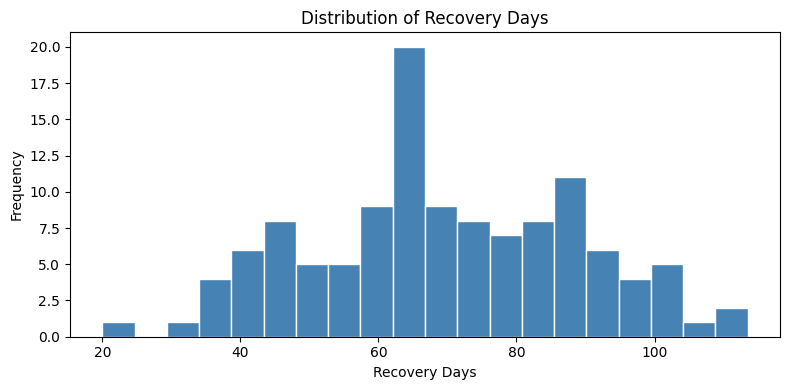

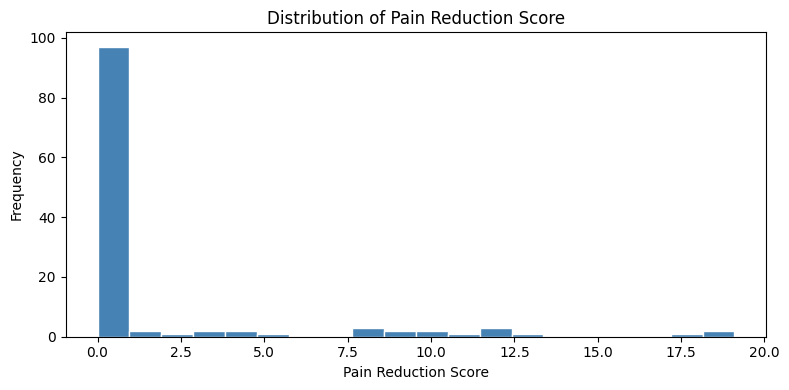

In [78]:
plt.figure(figsize=(8, 4))
plt.hist(df['Recovery_Days'], bins=20, color='steelblue', edgecolor='white')
plt.title('Distribution of Recovery Days')
plt.xlabel('Recovery Days')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.hist(df['Pain_Reduction_Score'], bins=20, color='steelblue', edgecolor='white')
plt.title('Distribution of Pain Reduction Score')
plt.xlabel('Pain Reduction Score')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

## Step 4 — Define Features & Targets

> - **X** = input features (the predictors the model learns from)
> - **y** = output targets — here we have **two columns** (multi-output)
>
> Unlike single-output regression where `y` is a 1-D array, here `y` is a **2-D DataFrame**
> with shape `(n_samples, 2)`.


In [39]:
features = ['Age', 'BMI', 'Blood_Pressure', 'Therapy_Hours', 'Medication_Dosage', 'Preexisting_Score']

X = df[features]
y = df[['Recovery_Days', 'Pain_Reduction_Score']]

print(f'Features : {features}')
print(f'X shape  : {X.shape}')
print(f'y shape  : {y.shape}')

Features : ['Age', 'BMI', 'Blood_Pressure', 'Therapy_Hours', 'Medication_Dosage', 'Preexisting_Score']
X shape  : (120, 6)
y shape  : (120, 2)


## Step 5 — Train / Test Split

> We reserve **20%** of data for testing and train on the remaining **80%**.
> `random_state=42` makes the split reproducible.


In [40]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f'Training samples : {X_train.shape[0]}')
print(f'Testing samples  : {X_test.shape[0]}')

Training samples : 96
Testing samples  : 24


## Step 6 — Handle Missing Values in Test Data (Safe Method)

> ⚠️ **Data Leakage Warning**
>
> When filling missing values, always use statistics computed **only from training data**.
> Using test-set statistics to fill missing values 'leaks' future information into training.
> Here we compute the mean from `X_train` and apply it to both sets.


In [75]:
# Compute mean from training data only
train_means = X_train.mean()

# Apply to both sets
X_train = X_train.fillna(train_means)
X_test  = X_test.fillna(train_means)

print('✅ Missing values in test data filled using training mean.')
print('Train missing:', X_train.isnull().sum().sum())
print('Test missing :', X_test.isnull().sum().sum())

✅ Missing values in test data filled using training mean.
Train missing: 0
Test missing : 0


## Step 8 — Build & Train the Multi-Output Model

> `MultiOutputRegressor(LinearRegression())` trains **one Linear Regression model per target**.
>
> Internally it fits:
> - Model A → predicts `Recovery_Days`
> - Model B → predicts `Pain_Reduction_Score`
>
> Both models share the same input features `X_train`.


In [42]:
base_model = LinearRegression()
model = MultiOutputRegressor(base_model)
model.fit(X_train, y_train)

print('✅ Model trained!')

✅ Model trained!


## Step 9 — Evaluate the Model

> We evaluate **each target separately** using three metrics:
>
> | Metric | Formula | What it means |
> |---|---|---|
> | **MAE** | avg(\|actual − predicted\|) | Average error in original units |
> | **RMSE** | √avg((actual − predicted)²) | Penalises large errors more |
> | **R²** | 1 − SS_res/SS_tot | % of variance explained (1.0 = perfect) |



### Evaluation Metric Formulas

**Mean Absolute Error (MAE):**
$$ \text{MAE} = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i| $$

**Root Mean Squared Error (RMSE):**
$$ \text{RMSE} = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2} $$

**R² (Coefficient of Determination):**
$$ R^2 = 1 - \frac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2} $$

Where $y_i$ = actual, $\hat{y}_i$ = predicted, $\bar{y}$ = mean of actuals, $n$ = test samples


In [60]:
y_pred = model.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print(f'MAE  : {mae:,.2f}')
print(f'RMSE : {rmse:,.2f}')
print(f'R²   : {r2:.4f}')
print(f'\n📌 R² of {r2:.2f} means the model explains {r2*100:.1f}% of the variance in house prices.')

MAE  : 3.42
RMSE : 4.64
R²   : 0.6186

📌 R² of 0.62 means the model explains 61.9% of the variance in house prices.


## Step 10 — Visualise Actual vs Predicted

> A scatter plot of **Actual vs Predicted** values is a quick sanity check.
> Points close to the diagonal line (y = x) indicate good predictions.


y_pred shape: (24,)
X_test length: 24


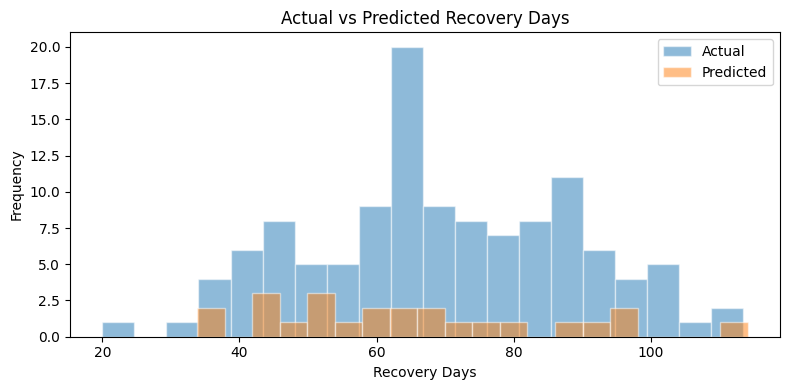

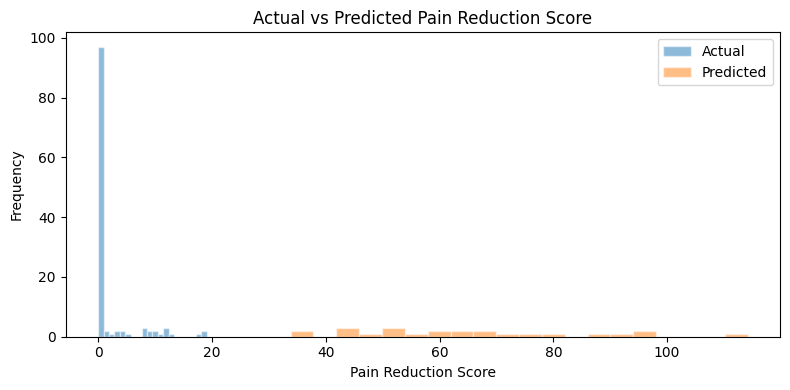

In [79]:
y_pred = np.array(y_pred).squeeze()

print("y_pred shape:", y_pred.shape)
print("X_test length:", len(X_test))

df['Predicted_Recovery_Days'] = np.nan
df.loc[X_test.index, 'Predicted_Recovery_Days'] = y_pred
plt.figure(figsize=(8, 4))

plt.hist(df['Recovery_Days'], bins=20, alpha=0.5, label='Actual', edgecolor='white')
plt.hist(df['Predicted_Recovery_Days'].dropna(), bins=20, alpha=0.5, label='Predicted', edgecolor='white')

plt.title('Actual vs Predicted Recovery Days')
plt.xlabel('Recovery Days')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()


df['Predicted_Pain_Reduction_Score'] = np.nan
df.loc[X_test.index, 'Predicted_Pain_Reduction_Score'] = y_pred
plt.figure(figsize=(8, 4))

plt.hist(df['Pain_Reduction_Score'], bins=20, alpha=0.5, label='Actual', edgecolor='white')
plt.hist(df['Predicted_Pain_Reduction_Score'].dropna(), bins=20, alpha=0.5, label='Predicted', edgecolor='white')

plt.title('Actual vs Predicted Pain Reduction Score')
plt.xlabel('Pain Reduction Score')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

## Step 11 — Predict on New Patient Data

> Now we use the trained model to predict outcomes for **two new patients**.
> The new data must be scaled using the **same scaler fitted on training data**.


In [74]:
new_patients = pd.DataFrame({
    'Age'               : [45,  72 ],
    'BMI'               : [24.5, 31.2],
    'Blood_Pressure'    : [120, 145 ],
    'Therapy_Hours'     : [12,   5  ],
    'Medication_Dosage' : [50,  80  ],
    'Preexisting_Score' : [2,    7  ]
})

# Fill any missing (none here, but good practice) then scale
new_patients_filled = new_patients.fillna(train_means)

preds = model.predict(new_patients_filled)

new_patients['Recovery_Days']      = preds[:, 0].round(1)
new_patients['Pain_Reduction_Score']     = preds[:, 1].round(1)

print('🏥 Predicted Patient Outcomes:')
print(new_patients.to_string(index=False))

🏥 Predicted Patient Outcomes:
 Age  BMI  Blood_Pressure  Therapy_Hours  Medication_Dosage  Preexisting_Score  Recovery_Days  Pain_Reduction_Score
  45 24.5             120             12                 50                  2           52.0                   4.2
  72 31.2             145              5                 80                  7          105.0                  -3.3
